# 06 — Como cada método interfere em imagens coloridas

Este notebook aplica transformações Albumentations a uma fotografia do **COCO 2017 validation** (`image_id=39769`) e mantém caixas e máscaras sincronizadas. Depois ilustra Mixup e CutMix com duas imagens CIFAR-10. As saídas alimentam as cenas Manim.

Fontes: [COCO](https://cocodataset.org/#download), [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html), [Albumentations](https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/). A fotografia e o recorte das anotações oficiais ficam em `data/raw/coco_demo/`. Este é um exemplo visual, não um treino de detecção no COCO.

In [1]:
from pathlib import Path
import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import albumentations as A
import cv2
from torchvision.datasets import ImageFolder

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'seminar_3/notebooks').is_dir())
SEMINAR = ROOT/'seminar_3'
OUT = SEMINAR/'data/outputs/color'
RAW = SEMINAR/'data/raw/coco_demo'
OUT.mkdir(parents=True, exist_ok=True)
image = np.asarray(Image.open(RAW/'000000039769.jpg').convert('RGB'))
metadata = json.loads((RAW/'annotations.json').read_text())
assert image.shape == (480, 640, 3) and metadata['image']['id'] == 39769

# Máscara de instância: 0=fundo, 1..N=objetos. Polígonos são os oficiais do COCO.
mask = np.zeros(image.shape[:2], dtype=np.uint8)
boxes, labels = [], []
selected = [ann for ann in metadata['annotations'] if ann['category_name'] in {'cat', 'remote'}]
for instance_id, ann in enumerate(selected, 1):
    for polygon in ann['segmentation']:
        points = np.asarray(polygon, dtype=np.float32).reshape(-1, 2).round().astype(np.int32)
        cv2.fillPoly(mask, [points], instance_id)
    x, y, width, height = ann['bbox']
    boxes.append([x, y, x+width, y+height])
    labels.append(ann['category_name'])
assert mask.max() == len(selected) and len(boxes) == len(labels) == 4

def annotated(rgb, instance_mask, bboxes, names):
    result = rgb.copy()
    foreground = instance_mask > 0
    result[foreground] = (0.72*result[foreground] + 0.28*np.array([20, 220, 180])).astype(np.uint8)
    for box, name in zip(bboxes, names, strict=True):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(result, (x1,y1), (x2,y2), (255,230,20), 3)
        cv2.putText(result, name, (x1,max(18,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,230,20), 2, cv2.LINE_AA)
    return result

original_annotated = annotated(image, mask, boxes, labels)
Image.fromarray(image).save(OUT/'coco_original.png')


## Transformações sobre imagem, máscara e caixas

Geometria altera pixels e coordenadas; efeitos fotométricos alteram só a imagem. Blur reduz alta frequência. Grayscale elimina cromaticidade. Cutout oculta evidência sem mover os rótulos. A caixa após rotação é o menor retângulo alinhado aos eixos que envolve o objeto transformado.

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


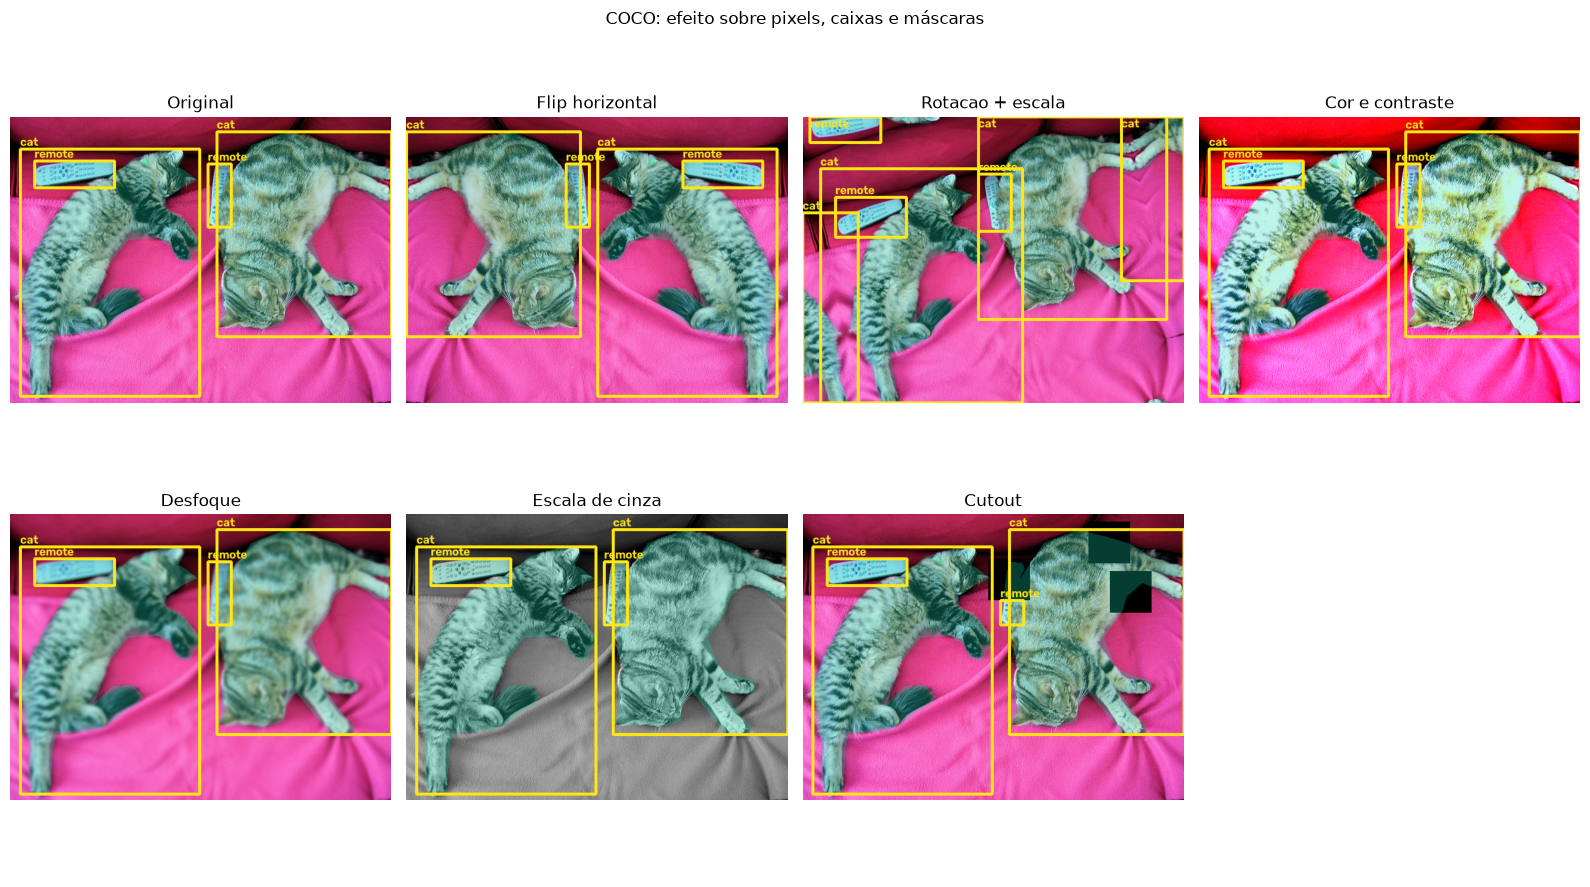

Sincronização geométrica e preservação fotométrica verificadas.


In [2]:
effects = {
    'Flip horizontal': A.HorizontalFlip(p=1),
    'Rotacao + escala': A.Affine(scale=(0.85,0.85), rotate=(15,15), border_mode=cv2.BORDER_REFLECT_101, p=1),
    'Cor e contraste': A.ColorJitter(brightness=(1.25,1.25), contrast=(1.2,1.2), saturation=(1.35,1.35), hue=(0.04,0.04), p=1),
    'Desfoque': A.GaussianBlur(blur_limit=(9,9), sigma_limit=(2,2), p=1),
    'Escala de cinza': A.ToGray(p=1),
    'Cutout': A.CoarseDropout(num_holes_range=(3,3), hole_height_range=(70,70), hole_width_range=(70,70), fill=0, p=1),
}
results = {'Original': dict(image=image, mask=mask, bboxes=boxes, labels=labels)}
for index, (name, effect) in enumerate(effects.items()):
    pipeline = A.Compose([effect], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.15), seed=558+index)
    results[name] = pipeline(image=image, mask=mask, bboxes=boxes, labels=labels)

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, (name, result) in zip(axes.flat, results.items(), strict=False):
    rendered = annotated(result['image'], result['mask'], result['bboxes'], result['labels'])
    filename = name.lower().replace(' ','_').replace('ç','c').replace('ã','a')
    Image.fromarray(rendered).save(OUT/f'coco_{filename}.png')
    ax.imshow(rendered); ax.set_title(name); ax.axis('off')
for ax in axes.flat[len(results):]: ax.axis('off')
fig.suptitle('COCO: efeito sobre pixels, caixas e máscaras')
fig.tight_layout(); fig.savefig(OUT/'coco_effects_grid.png', dpi=180, bbox_inches='tight'); plt.show()
assert np.array_equal(results['Cor e contraste']['mask'], mask)
assert np.array_equal(results['Desfoque']['mask'], mask)
assert np.array_equal(results['Escala de cinza']['mask'], mask)
assert np.array_equal(results['Cutout']['mask'], mask)
assert np.array_equal(results['Flip horizontal']['mask'], mask[:, ::-1])
print('Sincronização geométrica e preservação fotométrica verificadas.')


## Mixup e CutMix no CIFAR-10

Mixup combina todos os pixels e os dois rótulos. CutMix substitui uma região e pondera o rótulo pela área. A proporção de área é uma aproximação da contribuição semântica: um recorte pode conter mais ou menos do objeto.

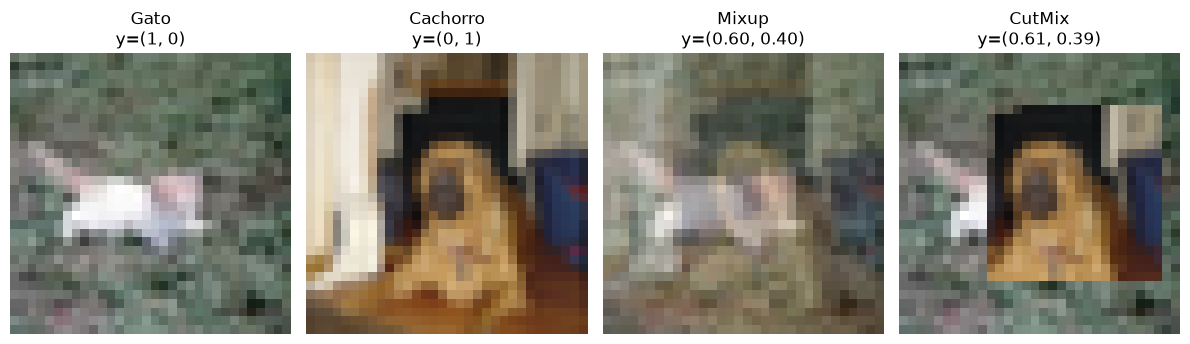

In [3]:
cifar = ImageFolder(SEMINAR/'data/raw/cifar10/train')
targets = np.asarray(cifar.targets)
a_id = np.flatnonzero(targets == 3)[7]  # cat
b_id = np.flatnonzero(targets == 5)[9]  # dog
a = np.asarray(Image.open(cifar.samples[a_id][0]).convert('RGB'))
b = np.asarray(Image.open(cifar.samples[b_id][0]).convert('RGB'))
lam = 0.60
mixup = np.rint(lam*a + (1-lam)*b).astype(np.uint8)
cutmix = a.copy(); x1,y1,x2,y2 = 10,6,30,26
cutmix[y1:y2,x1:x2] = b[y1:y2,x1:x2]
lam_cut = 1 - ((x2-x1)*(y2-y1))/(32*32)
assert np.isclose(lam_cut, 0.609375) and np.array_equal(cutmix[y1:y2,x1:x2], b[y1:y2,x1:x2])
items = [('Gato',a,'y=(1, 0)'),('Cachorro',b,'y=(0, 1)'),('Mixup',mixup,f'y=({lam:.2f}, {1-lam:.2f})'),('CutMix',cutmix,f'y=({lam_cut:.2f}, {1-lam_cut:.2f})')]
fig, axes = plt.subplots(1,4,figsize=(12,3.5))
for ax,(name,rgb,target) in zip(axes,items,strict=True):
    enlarged=Image.fromarray(rgb).resize((384,384),Image.Resampling.NEAREST)
    enlarged.save(OUT/f'cifar_{name.lower()}.png')
    ax.imshow(rgb); ax.set_title(f'{name}\n{target}'); ax.axis('off')
fig.tight_layout(); fig.savefig(OUT/'cifar_mix_examples.png',dpi=180,bbox_inches='tight'); plt.show()


## Leitura correta

As imagens comprovam o mecanismo e a coerência dos rótulos. Elas não comprovam ganho de acurácia; essa evidência vem do notebook 05. A animação `CocoTransformacoes` percorre todas as operações acima; `CifarMisturas` explica Mixup/CutMix; `CifarResultados` usa o CSV real do treinamento.